# 05 · Results on the real extract

Scores the models trained in `04_model_training.ipynb` on the real extract prepared by `02_preprocessing.ipynb`. Nothing is refitted here: every real landmark row is test data for models that were trained on the synthetic cohort.

| section | question |
|---|---|
| 1. Data scored | how many valves, rows and events the numbers below rest on |
| 2. Discrimination | does the model rank the valves that fail above those that do not (competing-risk AUC, Uno-style C-index) |
| 3. Overall accuracy | is the predicted risk closer to what happened than a single population rate (IPCW Brier, scaled Brier) |
| 4. Calibration | does 20 percent predicted mean 20 percent observed |
| 5. Clinical usefulness | would acting on the risk tiers help (decision curve, tiers, sensitivity and PPV at the tier cut-offs) |
| 6. Subgroups | SAVR vs TAVR, early vs late landmarks |
| 7. Run tracking | how this run compares with earlier runs, logged to `data/processed/results_log.csv` |
| 8. Interpretation | what the numbers do and do not support |

Every output is aggregate: counts, metrics and group-level plots. No patient identifier, row or note text is printed. Code: `pipeline/evaluation.py` and `pipeline/ml.py`.

**How to run for a given run.** `AVR_RUN=<run name>` selects `data/processed/runs/<run>/` (default `main`); `AVR_REAL_DIR` points to the prepared real tables (default `data/processed`). From `notebooks/`:

```
AVR_RUN=main uv run jupyter nbconvert --to notebook --execute --inplace 05_results.ipynb
```

## 0. Settings

In [1]:
from pathlib import Path
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 200)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
from pipeline import viz, ml, landmarks, evaluation as ev, ledger
for m in (viz, ml, landmarks, ev, ledger):
    importlib.reload(m)
viz.use_style()

PROCESSED = ROOT / "data" / "processed"
RUN = os.environ.get("AVR_RUN", "main")
RUN_DIR = PROCESSED / "runs" / RUN
REAL_DIR = Path(os.environ.get("AVR_REAL_DIR", PROCESSED))
HORIZONS = (2, 5, 8)
H = 5
N_BOOT = 500
SEED = 0
CAL_GROUPS = 3
THRESHOLDS = np.round(np.arange(0.01, 0.31, 0.01), 2)
MAIN = ["valve age only", "Cox, risk factors", "regression baseline", "gradient boosting", "gradient boosting, no constraints"]
LOG_PATH = PROCESSED / "results_log.csv"
WRITE_LOG = os.environ.get("AVR_WRITE_LOG", "1") != "0"

missing = ev.missing_inputs(RUN_DIR, REAL_DIR)
READY = not missing
if not READY:
    print(f"Cannot evaluate run '{RUN}'. Missing inputs:")
    for p in missing:
        print("  ", p.relative_to(ROOT) if p.is_relative_to(ROOT) else p)
    print("Run 02_preprocessing.ipynb for the real tables and 03 then 04 for the run. Every cell below is skipped.")

In [2]:
if READY:
    bundle, models = ev.load_run(RUN_DIR)
    LABEL = bundle["label"]
    TAG = f"real extract; trained on: {LABEL}"
    HORIZONS = tuple(h for h in HORIZONS if h in bundle["labels"]["horizons"]) or tuple(bundle["labels"]["horizons"])
    Xr, mr, real_outcomes = ev.score_real(bundle, REAL_DIR)
    preds = ev.predict_all(models, Xr, HORIZONS)
    MAIN = [m for m in MAIN if m in preds]
    display(pd.Series({"run": RUN, "training data": LABEL, "preset": bundle.get("preset"), "feature selection applied": bundle["selection"]["enabled"],
                       "endpoint": bundle["labels"]["endpoint"], "models loaded": len(models), "horizons (years)": HORIZONS,
                       "bootstrap resamples (by valve)": N_BOOT}, name="setting").to_frame())

,setting
run,final
training data,"synthetic, matched to real extract"
preset,ideal
feature selection applied,True
endpoint,stage2_or_worse
models loaded,8
horizons (years),"(2, 5, 8)"
bootstrap resamples (by valve),500


## 1. Data scored

The real extract after landmarking. Each valve contributes one row per landmark it survived event-free (6 months, 1 year, then yearly), so rows are not independent: every interval below resamples **valves**, not rows. Observed incidence is the Aalen-Johansen estimate, which treats death as a competing event and handles censoring.

,real extract
valves with a known implant year,117
valves scored (followed beyond the first landmark),51
landmark rows scored,301
landmark rows per valve (median / max),5 / 11
valves with a structural event,10
valves with a recorded death,0
TAVR / SAVR / unknown approach (valves),18 / 33 / 0
"follow-up after landmark, median (years)",4.0
"observed SVD within 2 years (Aalen-Johansen, rows)",5.0%
rows censored before 2 years,54


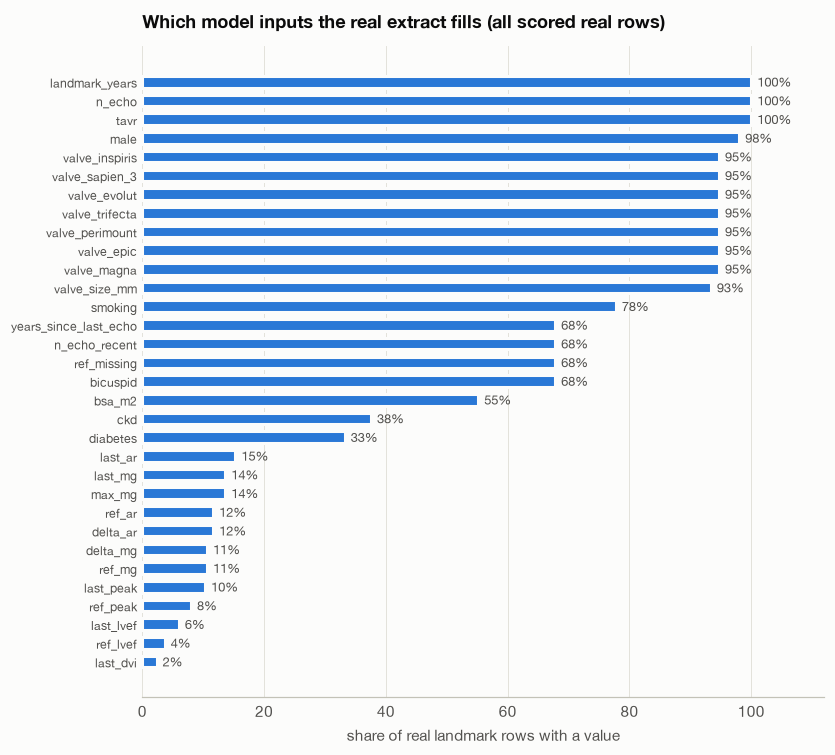

10 of 42 model inputs are empty for every real row and fall back to the models' missing-value handling: age_at_implant, anticoagulation, eoa_index_implant, ppm_grade, ref_dvi, ref_eoa, last_eoa, delta_dvi, delta_eoa, mg_slope


In [3]:
if READY:
    display(ev.cohort_summary(mr, real_outcomes, Xr, HORIZONS))
    availability = Xr.notna().mean()
    availability = availability[availability > 0].sort_values()
    fig, ax = plt.subplots(figsize=(8, max(3, 0.24 * len(availability))))
    viz.hbar(ax, list(availability.index[::-1]), list(availability.values[::-1] * 100), value_fmt="{:.0f}%", xlabel="share of real landmark rows with a value")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_title("Which model inputs the real extract fills (all scored real rows)")
    viz.save(fig, "05_input_availability")
    plt.show()
    empty_inputs = [c for c in Xr.columns if c not in availability.index]
    print(f"{len(empty_inputs)} of {len(Xr.columns)} model inputs are empty for every real row and fall back to the models' missing-value handling: {', '.join(empty_inputs)}")

## 2. Discrimination

**Competing-risk AUC** at each horizon: cases are rows with SVD by the horizon, controls are rows event-free past the horizon or dead first; inverse probability of censoring weights (IPCW) correct for rows lost to follow-up before the horizon.

**Uno-style C-index** up to the horizon: over all comparable pairs (a row with SVD at time t against a row still event-free after t, or one that died before t), the weighted share where the row with SVD had the higher predicted risk. It uses every event time, not only the horizon cut, so it is less jumpy than the AUC with few events. Both are 0.5 for a coin flip.

Intervals are 2.5th to 97.5th percentiles over valve-level bootstrap resamples.

In [4]:
if READY:
    perf = ev.performance(preds, mr)
    ci = ev.bootstrap(preds, mr, n_boot=N_BOOT, seed=SEED)
    full = perf.join(ci)
    order = list(preds)
    disc = pd.DataFrame({
        (f"{h} years", "AUC"): [f"{full.loc[(n, h), 'auc']:.2f} ({full.loc[(n, h), 'auc_lo']:.2f} to {full.loc[(n, h), 'auc_hi']:.2f})" for n in order]
        for h in HORIZONS} | {
        (f"{h} years", "C-index"): [f"{full.loc[(n, h), 'c_index']:.2f} ({full.loc[(n, h), 'c_index_lo']:.2f} to {full.loc[(n, h), 'c_index_hi']:.2f})" for n in order]
        for h in HORIZONS}, index=order).sort_index(axis=1, level=0, sort_remaining=False)
    disc.index.name = f"model ({LABEL} training, real extract)"
    display(disc)

2 years                                   5 years                                   8 years                     
                                                                    AUC              C-index                  AUC              C-index                  AUC              C-index
model (synthetic, matched to real extract train...                                                                                                                              
calendar schedule                                   0.61 (0.45 to 0.83)  0.60 (0.44 to 0.82)  0.65 (0.51 to 0.81)  0.63 (0.50 to 0.79)  0.29 (0.18 to 0.39)  0.34 (0.24 to 0.44)
valve age only                                      0.69 (0.50 to 0.89)  0.67 (0.49 to 0.88)  0.72 (0.54 to 0.89)  0.68 (0.52 to 0.86)  0.78 (0.64 to 0.91)  0.72 (0.60 to 0.85)
Cox, risk factors                                   0.68 (0.47 to 0.90)  0.68 (0.47 to 0.89)  0.71 (0.54 to 0.89)  0.69 (0.54 to 0.87)  0.78 (0.63 to 0.92)  0.72 (0.59 to 0.87)
regression baseline                                 0.69 (0.46 to 0.90)  0.68 (0.45 to 0.89)  0.72 (0.55 to 0.89)  0.70 (0.55 to 0.87)  0.79 (0.66 to 0.91)  0.73 (0.60 to 0.86)
gradient boosting                                   0.67 (0.44 to 0.89)  0.66 (0.44 to 0.89)  0.67 (0.46 to 0.89)  0.66 (0.46 to 0.86)  0.74 (0.54 to 0.91)  0.69 (0.53 to 0.87)
gradient boosting, no constraints                   0.67 (0.44 to 0.90)  0.66 (0.44 to 0.89)  0.66 (0.41 to 0.90)  0.65 (0.43 to 0.88)  0.72 (0.52 to 0.89)  0.69 (0.52 to 0.87)
regression baseline, recalibrated                   0.69 (0.46 to 0.90)  0.68 (0.45 to 0.89)  0.72 (0.55 to 0.89)  0.70 (0.55 to 0.87)  0.79 (0.66 to 0.91)  0.73 (0.60 to 0.86)
gradient boosting, recalibrated                     0.67 (0.44 to 0.89)  0.66 (0.44 to 0.89)  0.68 (0.46 to 0.89)  0.66 (0.47 to 0.86)  0.74 (0.55 to 0.91)  0.69 (0.53 to 0.86)

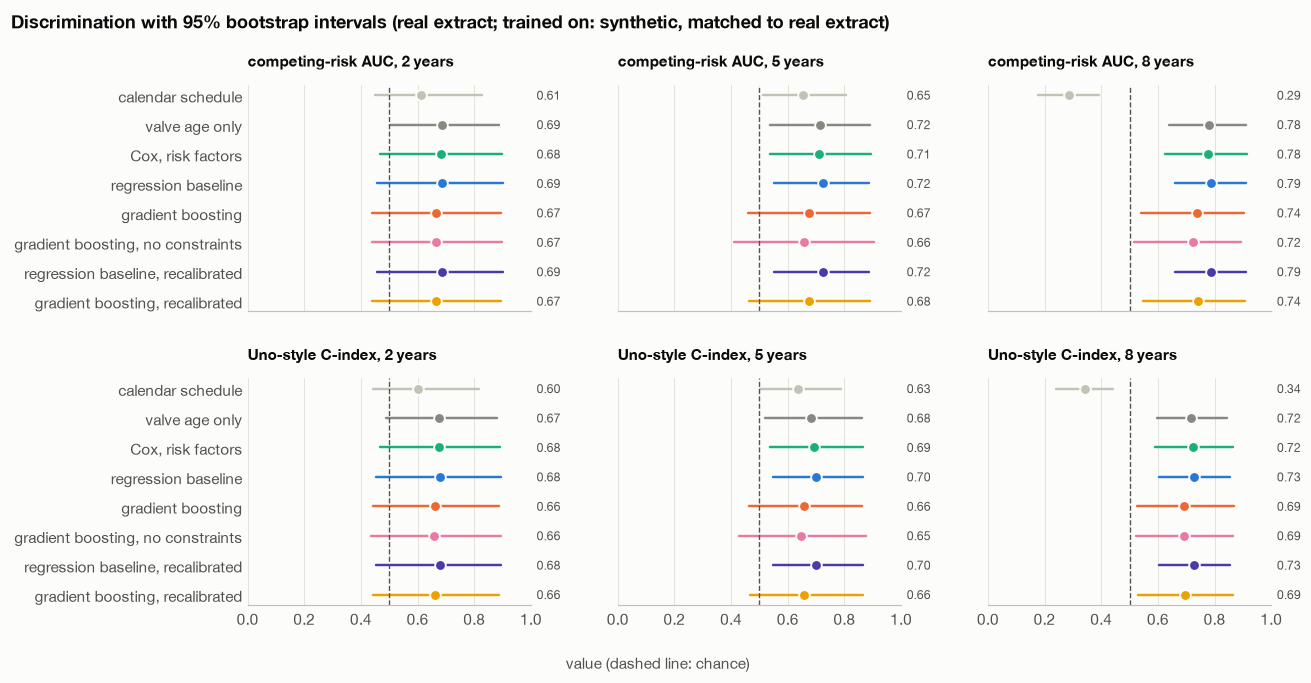

In [5]:
if READY:
    fig, axes = plt.subplots(2, len(HORIZONS), figsize=(12, 6.2), sharey=True, sharex=True)
    for r, (metric, name) in enumerate([("auc", "competing-risk AUC"), ("c_index", "Uno-style C-index")]):
        for c, h in enumerate(HORIZONS):
            ax = axes[r, c]
            for i, n in enumerate(order):
                row = full.loc[(n, h)]
                ax.plot([row[f"{metric}_lo"], row[f"{metric}_hi"]], [i, i], color=ev.color(n), linewidth=1.6, solid_capstyle="round")
                ax.plot(row[metric], i, "o", markersize=7, color=ev.color(n), markeredgecolor=viz.SURFACE, markeredgewidth=1.2)
                ax.text(1.02, i, f"{row[metric]:.2f}", va="center", ha="left", fontsize=8, color=viz.INK_SECONDARY, transform=ax.get_yaxis_transform())
            ax.axvline(0.5, color=viz.INK_SECONDARY, linewidth=0.9, linestyle="--")
            ax.set_xlim(0, 1)
            ax.set_yticks(range(len(order)), order)
            ax.grid(axis="y", visible=False)
            ax.set_title(f"{name}, {h} years", fontsize=10)
    axes[0, 0].invert_yaxis()
    fig.suptitle(f"Discrimination with 95% bootstrap intervals ({TAG})", x=0.01, ha="left", fontweight="bold", fontsize=12)
    fig.supxlabel("value (dashed line: chance)", fontsize=10, color=viz.INK_SECONDARY)
    fig.tight_layout(h_pad=2.2, w_pad=3)
    viz.save(fig, "05_discrimination_forest")
    plt.show()

## 3. Overall accuracy

The **IPCW Brier score** is the weighted mean squared gap between predicted risk and what happened by the horizon (lower is better). On its own it is hard to read because it depends on the event rate, so it is set against a **null model** that gives every row the observed Aalen-Johansen incidence. The **scaled Brier** (index of prediction accuracy) is `1 - Brier / null Brier`: positive means better than knowing only the population rate, zero means no gain, negative means worse. A model can rank well (high AUC) and still score below zero here if its absolute risks are off.

In [6]:
if READY:
    acc = pd.DataFrame({
        (f"{h} years", col): [full.loc[(n, h), key] for n in order]
        for h in HORIZONS for col, key in [("Brier", "brier"), ("null Brier", "brier_null"), ("scaled Brier", "scaled_brier")]}, index=order)
    acc[[(f"{h} years", "scaled Brier 95%") for h in HORIZONS]] = [[f"{full.loc[(n, h), 'scaled_brier_lo']:.2f} to {full.loc[(n, h), 'scaled_brier_hi']:.2f}" for h in HORIZONS] for n in order]
    acc = acc.sort_index(axis=1, level=0, sort_remaining=False)
    acc.index.name = "model (real extract)"
    display(acc.style.format("{:.3f}", subset=[c for c in acc.columns if "95%" not in c[1]]))

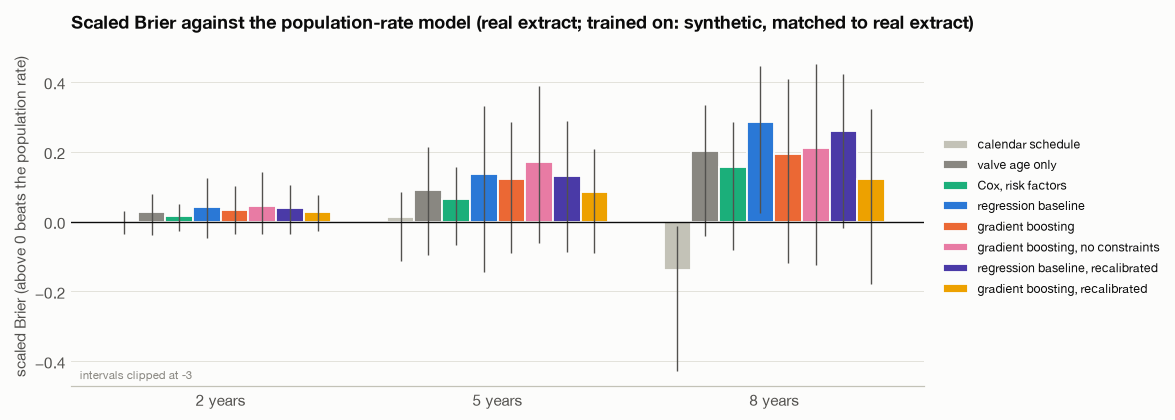

In [7]:
if READY:
    fig, ax = plt.subplots(figsize=(10, 4))
    width = 0.8 / len(order)
    x = np.arange(len(HORIZONS))
    for i, n in enumerate(order):
        pos = x + (i - (len(order) - 1) / 2) * width
        vals = [full.loc[(n, h), "scaled_brier"] for h in HORIZONS]
        lo = [full.loc[(n, h), "scaled_brier_lo"] for h in HORIZONS]
        hi = [full.loc[(n, h), "scaled_brier_hi"] for h in HORIZONS]
        ax.bar(pos, vals, width=width, color=ev.color(n), edgecolor=viz.SURFACE, linewidth=1.2, label=n)
        ax.vlines(pos, lo, hi, color=viz.INK_SECONDARY, linewidth=0.9)
    ax.axhline(0, color=viz.INK, linewidth=0.9)
    ax.set_xticks(x, [f"{h} years" for h in HORIZONS])
    ax.set_ylabel("scaled Brier (above 0 beats the population rate)")
    ax.grid(axis="x", visible=False)
    ax.legend(fontsize=8, ncol=1, loc="center left", bbox_to_anchor=(1.01, 0.5))
    ax.set_ylim(max(-3, ax.get_ylim()[0]), 0.5)
    ax.text(0.01, 0.02, "intervals clipped at -3", transform=ax.transAxes, fontsize=7.5, color=viz.MUTED)
    ax.set_title(f"Scaled Brier against the population-rate model ({TAG})")
    viz.save(fig, "05_scaled_brier")
    plt.show()

## 4. Calibration

**Calibration in the large**: the mean predicted risk against the observed Aalen-Johansen incidence at each horizon. The observed-to-expected ratio (O/E) is 1 when the average is right, below 1 when the model overpredicts.

**Calibration by risk group** at 5 years: rows split into equal thirds by predicted risk, and within each third the mean predicted risk is set against the observed incidence. With 10 valves with an event, three groups is the most the data can carry, and each observed value is itself uncertain by several percentage points.

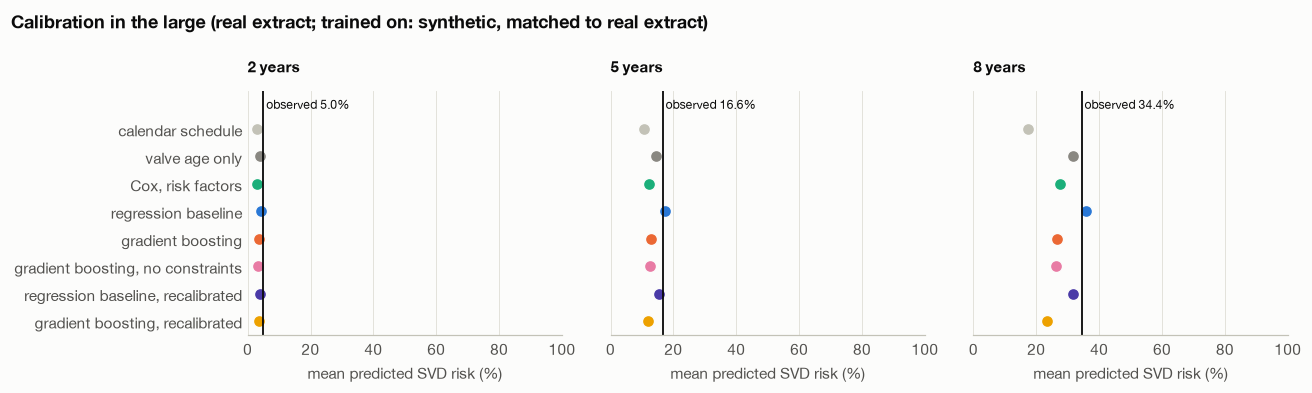

In [8]:
if READY:
    citl = pd.DataFrame({(f"{h} years", col): [full.loc[(n, h), key] for n in order]
                         for h in HORIZONS for col, key in [("mean predicted", "mean_predicted"), ("observed", "observed"), ("O/E", "oe_ratio")]}, index=order)
    citl.index.name = "model (real extract)"
    display(citl.style.format("{:.1%}").format("{:.2f}", subset=[c for c in citl.columns if c[1] == "O/E"]))

    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(12, 3.6), sharey=True)
    for c, h in enumerate(HORIZONS):
        ax = axes[c]
        for i, n in enumerate(order):
            ax.plot(full.loc[(n, h), "mean_predicted"] * 100, i, "o", markersize=8, color=ev.color(n), markeredgecolor=viz.SURFACE)
        obs = full.loc[(order[0], h), "observed"] * 100
        ax.axvline(obs, color=viz.INK, linewidth=1.2)
        ax.text(obs, -0.9, f" observed {obs:.1f}%", fontsize=8, color=viz.INK, va="center")
        ax.set_yticks(range(len(order)), order)
        ax.set_ylim(len(order) - 0.5, -1.4)
        ax.set_xlim(0, 100)
        ax.grid(axis="y", visible=False)
        ax.set_xlabel("mean predicted SVD risk (%)")
        ax.set_title(f"{h} years", fontsize=10)
    fig.suptitle(f"Calibration in the large ({TAG})", x=0.01, ha="left", fontweight="bold", fontsize=12)
    fig.tight_layout(w_pad=2)
    viz.save(fig, "05_calibration_in_the_large")
    plt.show()

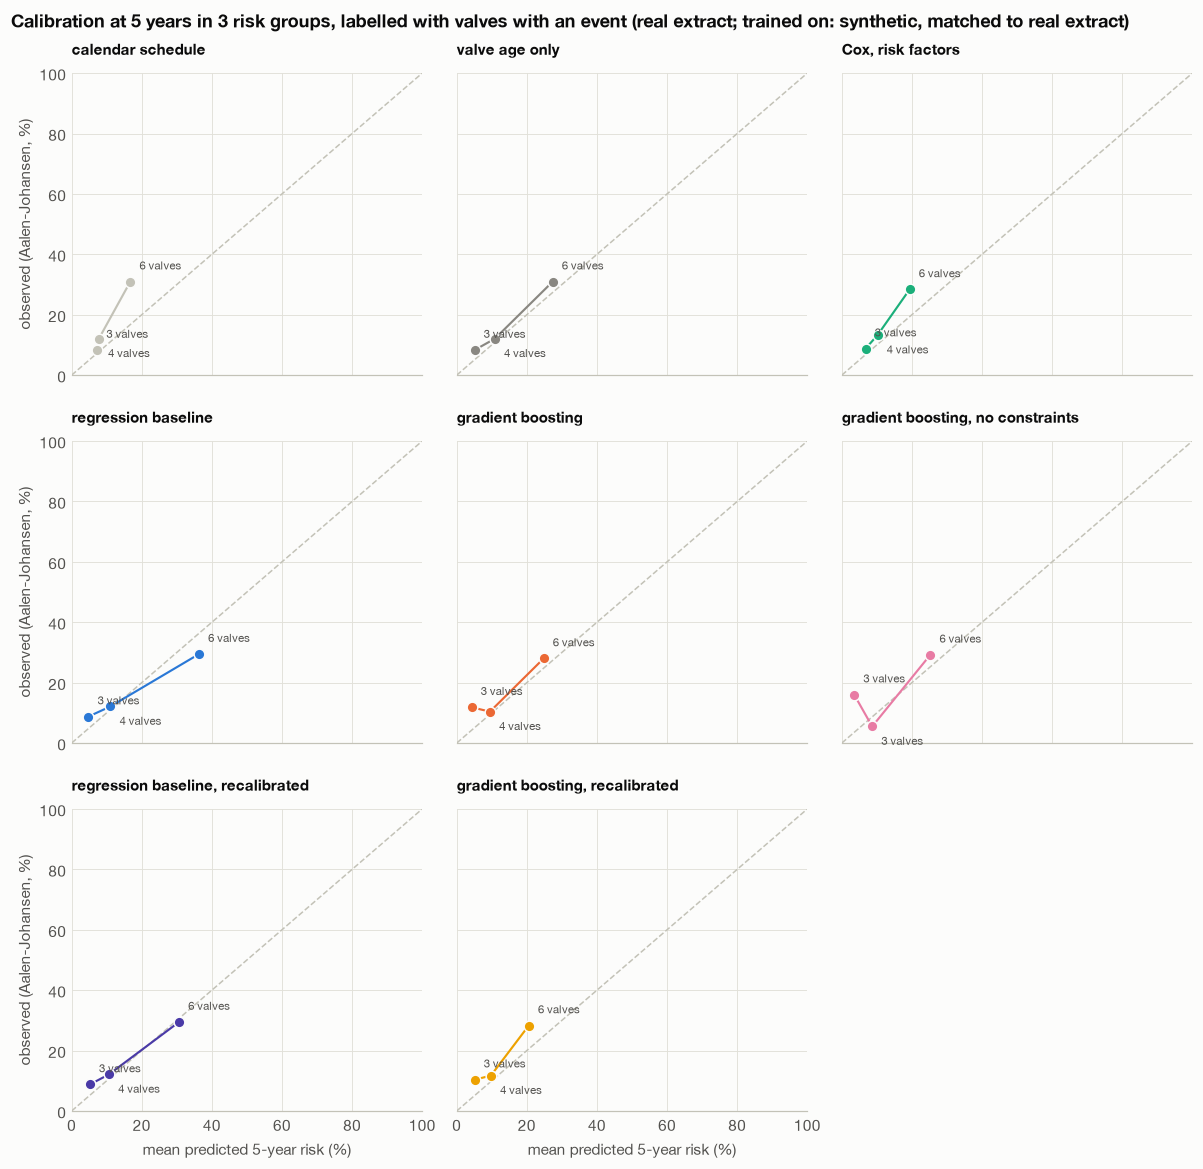

In [9]:
if READY:
    cal = {n: ev.calibration_groups(preds[n][H], mr, H, CAL_GROUPS) for n in order}
    cal_table = pd.concat(cal, names=["model", "risk group"])
    display(cal_table.style.format({"predicted_low": "{:.1%}", "predicted_high": "{:.1%}", "mean_predicted": "{:.1%}", "observed": "{:.1%}"}))

    ncol = 3
    nrow = int(np.ceil(len(order) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(11, 3.6 * nrow), sharex=True, sharey=True)
    for ax, n in zip(axes.flat, order):
        g = cal[n]
        ax.plot([0, 100], [0, 100], color=viz.AXIS, linewidth=1, linestyle="--")
        ax.plot(g.mean_predicted * 100, g.observed * 100, "-o", color=ev.color(n), markersize=7, linewidth=1.4, markeredgecolor=viz.SURFACE)
        for k, r in g.iterrows():
            ax.annotate(f"{int(r.valves_with_event)} valves", (r.mean_predicted * 100, r.observed * 100), textcoords="offset points", xytext=(6, 8) if k % 2 else (6, -12), fontsize=7.5, color=viz.INK_SECONDARY)
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_title(n, fontsize=9.5)
    for ax in axes[-1]:
        ax.set_xlabel("mean predicted 5-year risk (%)")
    for ax in axes[:, 0]:
        ax.set_ylabel("observed (Aalen-Johansen, %)")
    for ax in list(axes.flat)[len(order):]:
        ax.set_visible(False)
    fig.suptitle(f"Calibration at {H} years in {CAL_GROUPS} risk groups, labelled with valves with an event ({TAG})", x=0.01, ha="left", fontweight="bold", fontsize=11.5)
    fig.tight_layout(h_pad=1.5)
    viz.save(fig, "05_calibration_groups")
    plt.show()

## 5. Clinical usefulness

**Decision curve.** The decision here is "move this valve to a closer echo schedule". At a threshold probability *t* a clinician accepts that many extra echoes to catch one failing valve early, with the exchange rate *t / (1 - t)*. Net benefit counts true positives minus false positives weighted by that rate, per row scored, with observed outcomes from Aalen-Johansen within the flagged rows. A model is useful over the thresholds where it sits above both **treat all** (everyone on the intensive schedule) and **treat none** (everyone on the guideline calendar). The clinically relevant range is roughly 5 to 20 percent, the span of the protocol's risk tiers.

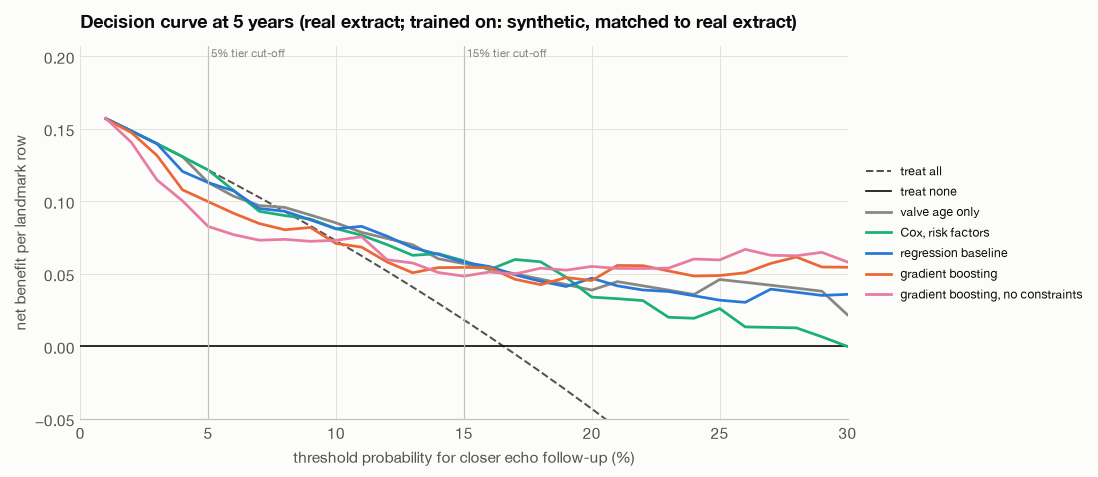

,5%,10%,15%,20%
net benefit at threshold,,,,
valve age only,0.113,0.085,0.057,0.039
"Cox, risk factors",0.122,0.081,0.059,0.034
regression baseline,0.113,0.081,0.058,0.047
gradient boosting,0.100,0.071,0.054,0.045
"gradient boosting, no constraints",0.083,0.073,0.048,0.055
treat all,0.122,0.073,0.018,-0.043
treat none,0.000,0.000,0.000,0.000


In [10]:
if READY:
    dca = {n: ev.net_benefit(preds[n][H], mr, H, THRESHOLDS) for n in MAIN}
    all_nb = ev.treat_all(mr, H, THRESHOLDS)
    fig, ax = plt.subplots(figsize=(9, 4.4))
    ax.plot(THRESHOLDS * 100, all_nb, color=viz.INK_SECONDARY, linewidth=1.3, linestyle="--", label="treat all")
    ax.axhline(0, color=viz.INK, linewidth=1.1, label="treat none")
    for n in MAIN:
        ax.plot(THRESHOLDS * 100, dca[n].net_benefit, color=ev.color(n), linewidth=1.8, label=n)
    for cut, _, _ in ml.RISK_TIERS[:-1]:
        ax.axvline(cut * 100, color=viz.AXIS, linewidth=0.8)
        ax.text(cut * 100, 1.0, f" {cut:.0%} tier cut-off", fontsize=7.5, color=viz.MUTED, transform=ax.get_xaxis_transform(), va="top")
    obs = ml.aalen_johansen(mr.time_to_end, mr.status, H)
    ax.set_ylim(-0.05, max(obs, 0.02) * 1.25)
    ax.set_xlim(0, 30)
    ax.set_xlabel("threshold probability for closer echo follow-up (%)")
    ax.set_ylabel("net benefit per landmark row")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
    ax.set_title(f"Decision curve at {H} years ({TAG})")
    viz.save(fig, "05_decision_curve")
    plt.show()
    at = [0.05, 0.10, 0.15, 0.20]
    nb_table = pd.DataFrame({f"{t:.0%}": {**{n: dca[n].loc[t, "net_benefit"] for n in MAIN}, "treat all": all_nb.loc[t], "treat none": 0.0} for t in at})
    nb_table.index.name = "net benefit at threshold"
    display(nb_table.style.format("{:.3f}"))

**Risk tiers.** The protocol maps the 5-year risk to an echo schedule: under 5 percent the guideline calendar, 5 to 15 percent an echo every 2 years, 15 percent or more a yearly echo. Below: how the real rows spread across tiers under each model, and the observed incidence in each tier. A useful model puts the events in the high tier and leaves the low tier nearly event-free.

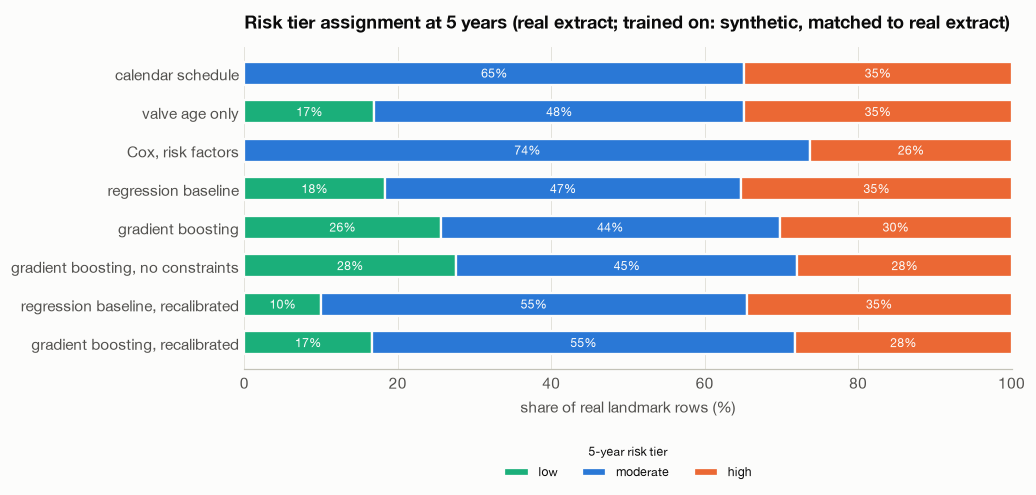

In [11]:
if READY:
    tiers = pd.concat({n: ev.tier_table(preds[n][H], mr, H) for n in order}, names=["model", "tier"])
    display(tiers.drop(columns="action").style.format({"share": "{:.0%}", "mean_predicted": "{:.1%}", "observed": "{:.1%}"}, na_rep="-"))
    names = [t[1] for t in ml.RISK_TIERS]
    tier_colors = [viz.SERIES[2], viz.SERIES[0], viz.SERIES[1]]
    fig, ax = plt.subplots(figsize=(9, 3.8))
    left = np.zeros(len(order))
    for name, col in zip(names, tier_colors):
        share = np.array([tiers.loc[(n, name), "share"] for n in order])
        ax.barh(range(len(order)), share * 100, left=left, color=col, height=0.6, edgecolor=viz.SURFACE, linewidth=1.5, label=name)
        for i, (l, s) in enumerate(zip(left, share)):
            if s >= 0.08:
                ax.text(l + s * 50, i, f"{s:.0%}", ha="center", va="center", fontsize=8, color=viz.SURFACE)
        left += share * 100
    ax.set_yticks(range(len(order)), order)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("share of real landmark rows (%)")
    ax.legend(title="5-year risk tier", fontsize=8, title_fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.2))
    ax.set_title(f"Risk tier assignment at {H} years ({TAG})")
    viz.save(fig, "05_risk_tiers")
    plt.show()

**Sensitivity, specificity, PPV and NPV at the tier cut-offs.** A row counts as flagged when its 5-year risk is at or above the cut-off. All four values are IPCW-weighted, so rows censored before 5 years do not count as event-free.

Accuracy is shown only to make one point: with an event rate near 17 percent, a rule that flags nobody is right for about 83 percent of rows and catches no failing valve. In surveillance the cost of a missed failing valve (a late reintervention, a failing valve in a frail patient) is far higher than an extra echo, so sensitivity and NPV at a low cut-off matter more than accuracy.

In [12]:
if READY:
    thr = pd.DataFrame([{"model": n, **ev.threshold_metrics(preds[n][H], mr, H, cut)} for cut in (ml.RISK_TIERS[0][0], ml.RISK_TIERS[1][0]) for n in order])
    thr["cutoff"] = thr.cutoff.map("{:.0%}".format)
    thr = thr.set_index(["cutoff", "model"])
    thr.columns = ["rows flagged", "sensitivity", "specificity", "PPV", "NPV", "accuracy", "accuracy if nobody flagged"]
    display(thr.style.format("{:.0%}", na_rep="-"))

## 6. Subgroups

Discrimination at 5 years within SAVR and TAVR valves and within early and late landmarks. The AUC is shown only when a subgroup has at least 3 valves with an event and 3 rows event-free past 5 years; otherwise the cell is empty. With 10 valves with an event in total, no subgroup difference here can be told apart from chance; the table is there to show the counts a real validation would need.

,rows,valves,valves_with_event,rows_event_free_past_horizon,observed,valve age only,"Cox, risk factors",regression baseline,gradient boosting,"gradient boosting, no constraints"
subgroup,,,,,,,,,,
SAVR,244,33,8,123,17.4%,0.74,0.74,0.75,0.70,0.68
TAVR,57,18,1,4,4.8%,-,-,-,-,-
landmark under 2 years,91,51,3,48,9.1%,0.49,0.39,0.48,0.12,0.07
landmark 2 to 4 years,105,37,4,46,11.7%,0.65,0.61,0.72,0.46,0.46
landmark 5 years or later,105,24,6,33,28.9%,0.74,0.78,0.74,0.81,0.85


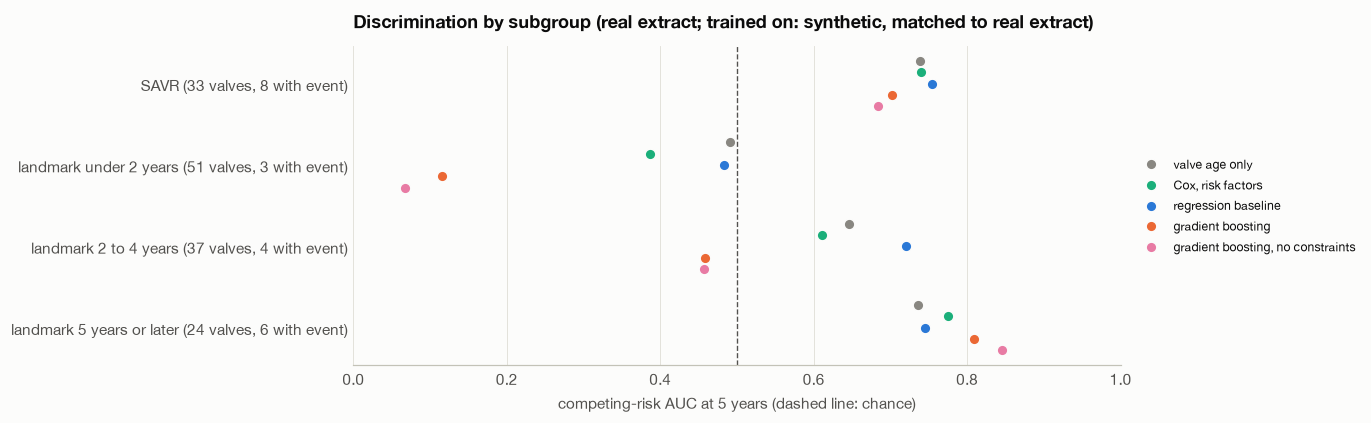

In [13]:
if READY:
    lm_years = mr.landmark_years.to_numpy()
    tavr = Xr["tavr"].to_numpy() if "tavr" in Xr else np.full(len(Xr), np.nan)
    groups = {"SAVR": tavr == 0, "TAVR": tavr == 1, "landmark under 2 years": lm_years < 2,
              "landmark 2 to 4 years": (lm_years >= 2) & (lm_years < 5), "landmark 5 years or later": lm_years >= 5}
    sub = ev.subgroup_table({n: preds[n] for n in MAIN}, mr, H, groups)
    display(sub.style.format({"observed": "{:.1%}", **{n: "{:.2f}" for n in MAIN}}, na_rep="-"))
    shown = sub[MAIN].dropna(how="all")
    if len(shown):
        fig, ax = plt.subplots(figsize=(9, 0.9 + 0.55 * len(shown) * 1.3))
        step = 0.7 / len(MAIN)
        for j, n in enumerate(MAIN):
            ys = np.arange(len(shown)) + (j - (len(MAIN) - 1) / 2) * step
            ax.plot(shown[n], ys, "o", color=ev.color(n), markersize=7, markeredgecolor=viz.SURFACE, label=n)
        ax.set_yticks(range(len(shown)), [f"{g} ({sub.loc[g, 'valves']} valves, {sub.loc[g, 'valves_with_event']} with event)" for g in shown.index])
        ax.invert_yaxis()
        ax.axvline(0.5, color=viz.INK_SECONDARY, linewidth=0.9, linestyle="--")
        ax.set_xlim(0, 1)
        ax.grid(axis="y", visible=False)
        ax.set_xlabel(f"competing-risk AUC at {H} years (dashed line: chance)")
        ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
        ax.set_title(f"Discrimination by subgroup ({TAG})")
        viz.save(fig, "05_subgroups")
        plt.show()
    else:
        print("No subgroup has enough events for an AUC.")

## 7. Run tracking

Each execution appends one row per model and horizon to `data/processed/results_log.csv` (gitignored, local only) with the time, git commit, run name, training label, whether feature selection was on, and the metrics above. The second table re-scores every run found under `data/processed/runs/` on the current real extract, so runs trained at different times are compared on the same data. The last plot follows the logged 5-year AUC over time.

In [14]:
if READY:
    entry = ev.log_rows(RUN, bundle, perf, ci, mr, ROOT)
    if WRITE_LOG:
        log = ev.append_log(LOG_PATH, entry)
        recorded = ledger.record(RUN, RUN_DIR, perf, ci, mr)
        print(f"ledger entry {recorded['id']} (settings {recorded['config_hash']}) added to {ledger.LEDGER_FILE.relative_to(ROOT)}")
        print(f"appended {len(entry)} rows to {LOG_PATH.relative_to(ROOT)}; the log now holds {len(log)} rows from {log.timestamp.nunique()} executions")
    else:
        log = pd.read_csv(LOG_PATH) if LOG_PATH.exists() else entry
    runs = ev.compare_runs(PROCESSED, REAL_DIR, horizon=H)
    if len(runs) and "auc" in runs:
        board = runs.pivot_table(index=["run", "trained", "label", "selection_enabled"], columns="model", values="auc")
        board = board[[c for c in order if c in board.columns]]
        display(board.style.format("{:.2f}").set_caption(f"{H}-year competing-risk AUC on the current real extract, every run"))

ledger entry 2026-09-17T00:47:15_final (settings 0ec23036b5) added to results/runs.jsonl
appended 24 rows to data/processed/results_log.csv; the log now holds 588 rows from 25 executions


,,,model,calendar schedule,valve age only,"Cox, risk factors",regression baseline,gradient boosting,"gradient boosting, no constraints","regression baseline, recalibrated","gradient boosting, recalibrated"
run,trained,label,selection_enabled,,,,,,,,
final,2026-09-17T00:46,"synthetic, matched to real extract",True,0.65,0.72,0.71,0.72,0.67,0.66,0.72,0.68
fixed_v2_1,2026-09-16T20:26,"synthetic, matched to real extract",True,0.65,0.72,0.72,0.76,0.76,0.71,0.76,0.76
fixed_v2_2,2026-09-16T20:27,"synthetic, matched to real extract",True,0.65,0.71,0.71,0.71,0.75,0.44,0.71,0.75
fixed_v2_3,2026-09-16T20:28,"synthetic, matched to real extract",True,0.65,0.72,0.72,0.72,0.68,0.37,0.72,0.68
fixed_v2_4,2026-09-16T20:28,"synthetic, matched to real extract",True,0.65,0.72,0.72,0.67,0.65,0.52,0.67,0.65
fixed_v2_5,2026-09-16T20:29,"synthetic, matched to real extract",True,0.65,0.72,0.71,0.74,0.47,0.34,0.74,0.48
gen3_v2_1,2026-09-17T00:29,"synthetic, matched to real extract",True,0.65,0.72,0.72,0.68,0.67,0.66,0.68,0.67
gen3_v2_2,2026-09-17T00:35,"synthetic, matched to real extract",True,0.65,0.72,0.71,0.73,0.69,0.61,0.73,0.69
gen3_v2_3,2026-09-17T00:33,"synthetic, matched to real extract",True,0.65,0.72,0.71,0.69,0.56,0.51,0.69,0.58


### Run ledger

Every evaluation is also recorded in the committed ledger (`results/runs.jsonl`, readable summary in `results/LEDGER.md`): the run's full settings (data, labels, matching, feature selection, training) next to its real-extract metrics, with the git commit it ran on. Set `AVR_NOTE` to attach a short description of what the run tries.

In [15]:
ledger_table = ledger.table(H)
if len(ledger_table):
    show = ledger_table[ledger_table.model.isin(ledger.HEADLINE_MODELS)]
    display(show.pivot_table(index=["time", "run", "config", "note", "n_features", "real_events"], columns="model", values="auc", aggfunc="first")
            .reindex(columns=[m for m in ledger.HEADLINE_MODELS if m in set(show.model)]).style.format("{:.2f}", na_rep="")
            .set_caption(f"{H}-year AUC on the real extract, every ledger entry"))
else:
    print("The ledger is empty; it fills when this notebook runs with the log enabled.")

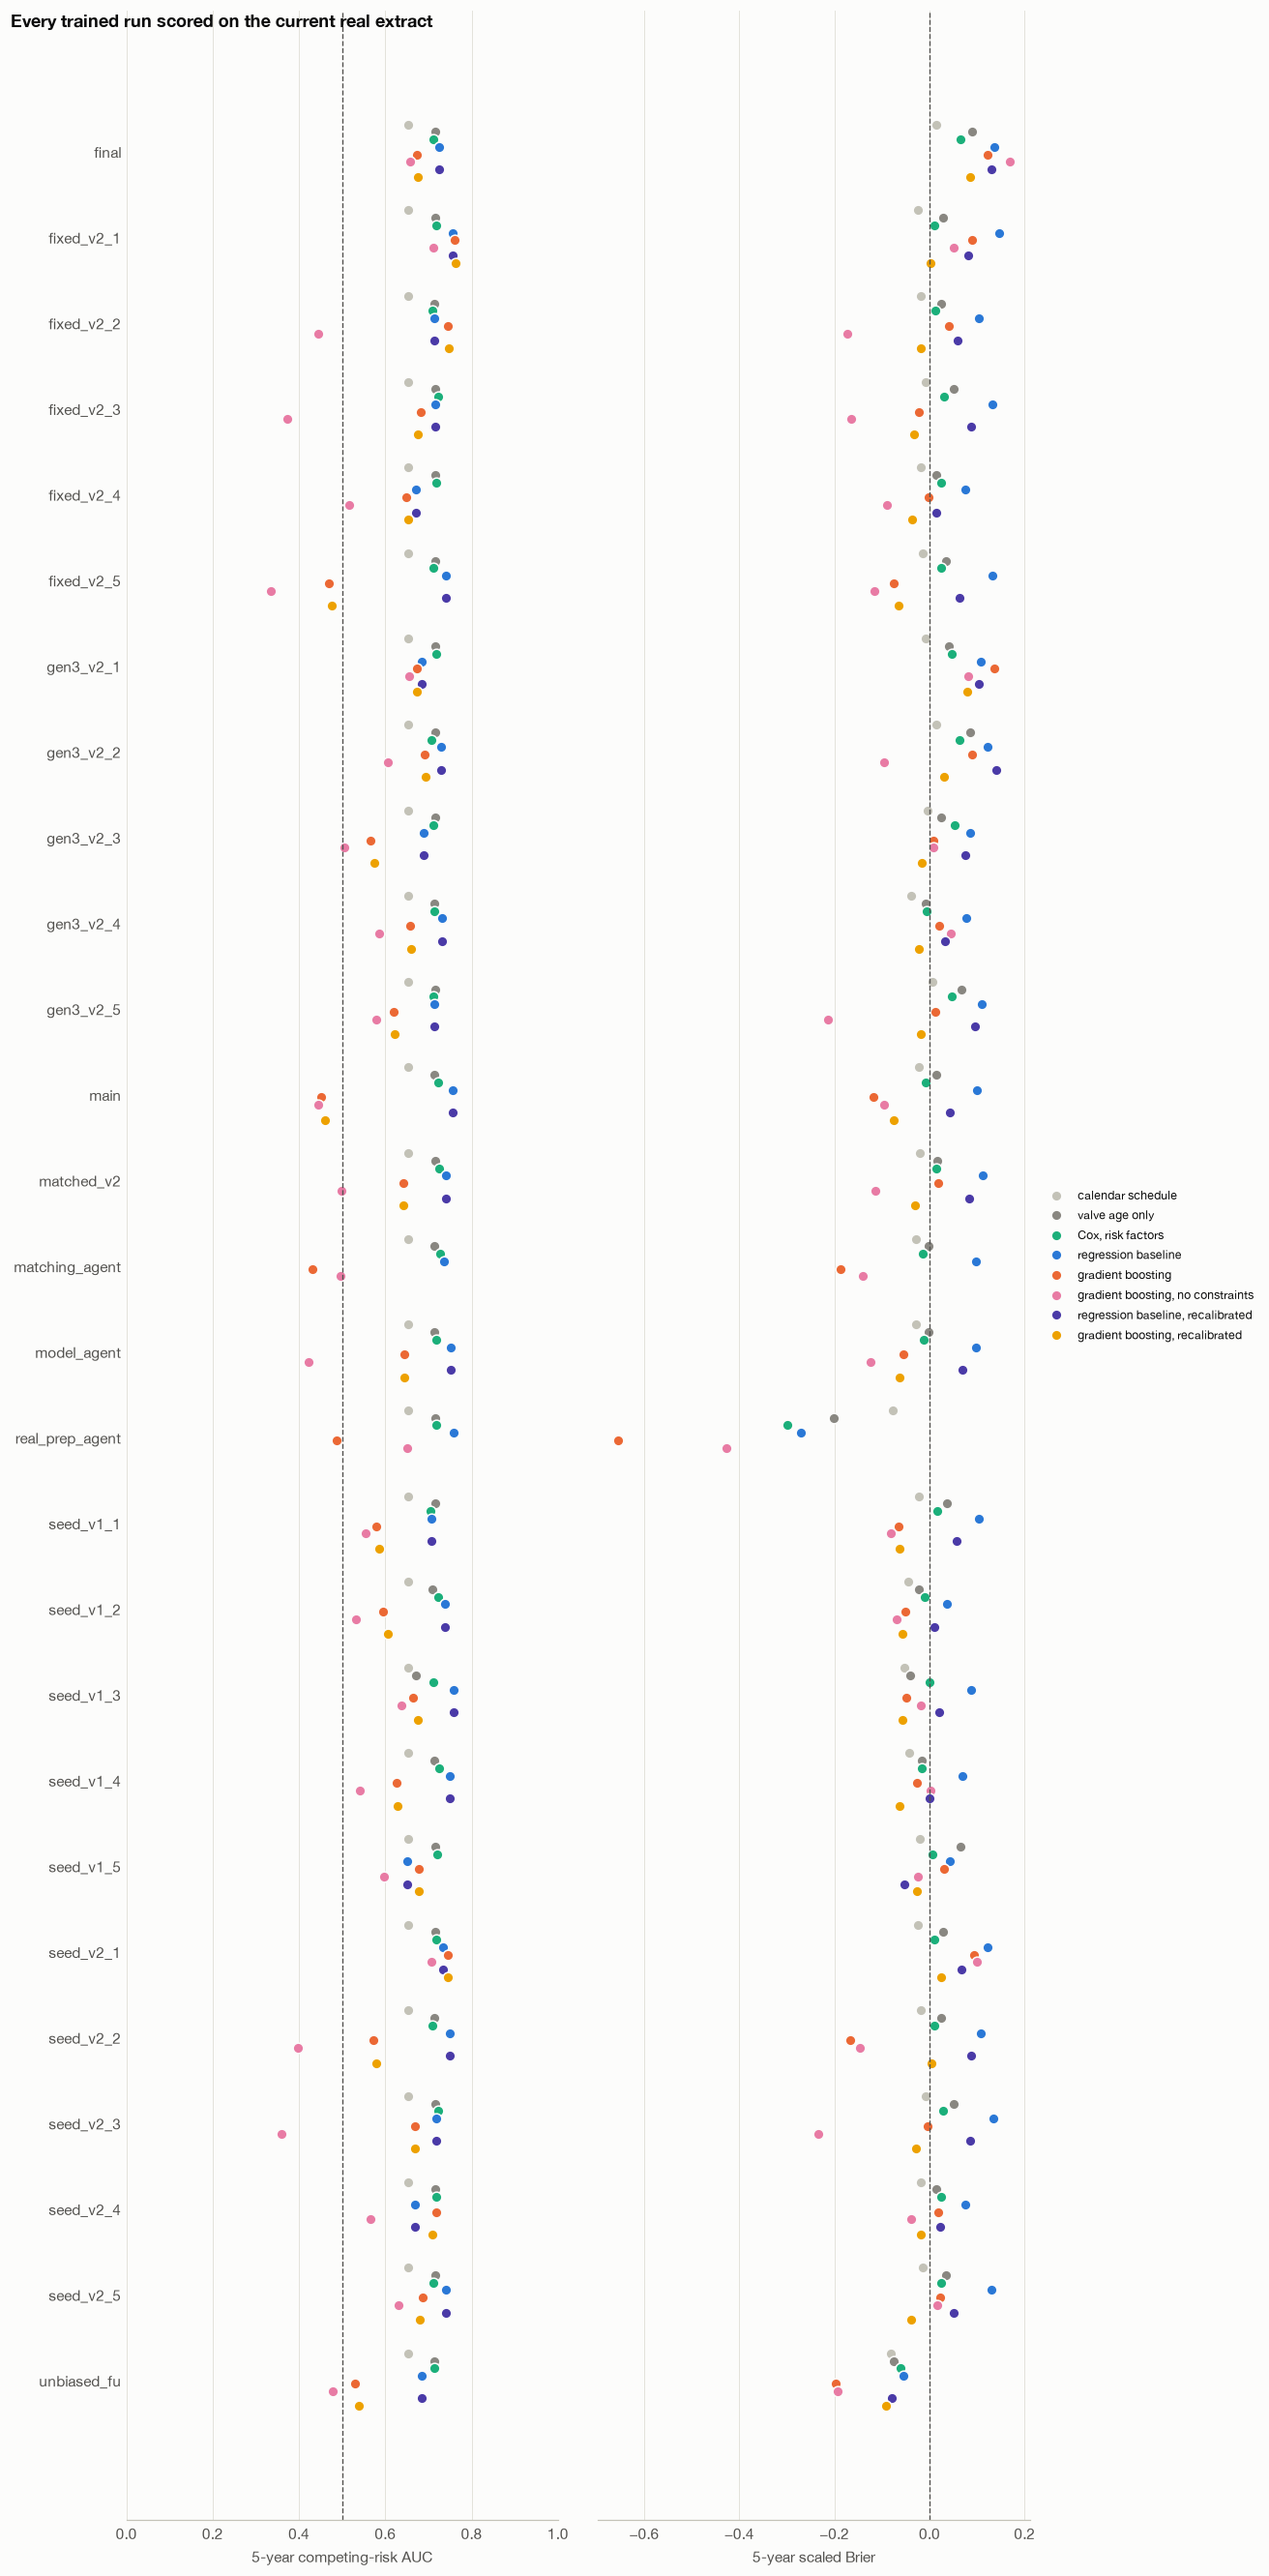

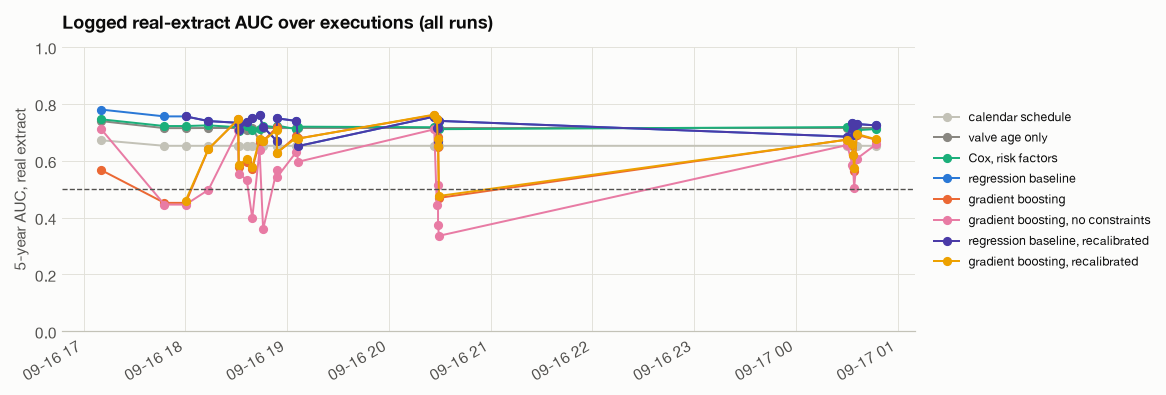

timestamp                               label  selection_enabled    auc  auc_lo  auc_hi  c_index  scaled_brier  oe_ratio
run   model                                                                                                                                                                
main  calendar schedule                  2026-09-16T18:00:07  synthetic, matched to real extract               True  0.652   0.512   0.805    0.634        -0.023     2.051
      valve age only                     2026-09-16T18:00:07  synthetic, matched to real extract               True  0.715   0.538   0.892    0.681         0.014     1.808
      Cox, risk factors                  2026-09-16T18:00:07  synthetic, matched to real extract               True  0.722   0.551   0.882    0.681        -0.008     1.918
      regression baseline                2026-09-16T18:00:07  synthetic, matched to real extract               True  0.756   0.603   0.886    0.722         0.099     1.489
      gradient boosting                  2026-09-16T18:00:07  synthetic, matched to real extract               True  0.452   0.246   0.665    0.428        -0.119     2.032
...                                                      ...                                 ...                ...    ...     ...     ...      ...           ...       ...
final regression baseline                2026-09-17T00:47:15  synthetic, matched to real extract               True  0.724   0.553   0.888    0.699         0.136     0.955
      gradient boosting                  2026-09-17T00:47:15  synthetic, matched to real extract               True  0.674   0.460   0.890    0.656         0.121     1.294
      gradient boosting, no constraints  2026-09-17T00:47:15  synthetic, matched to real extract               True  0.657   0.411   0.903    0.648         0.169     1.331
      regression baseline, recalibrated  2026-09-17T00:47:15  synthetic, matched to real extract               True  0.724   0.553   0.888    0.699         0.130     1.072
      gradient boosting, recalibrated    2026-09-17T00:47:15  synthetic, matched to real extract               True  0.675   0.462   0.891    0.658         0.085     1.406

[184 rows x 9 columns]

In [16]:
if READY:
    if len(runs) and "auc" in runs:
        run_names = list(dict.fromkeys(runs.run))
        fig, axes = plt.subplots(1, 2, figsize=(12, 0.9 + 0.55 * max(len(run_names), 2) * 1.6), sharey=True)
        step = 0.7 / len(order)
        for ax, metric, xlabel in [(axes[0], "auc", f"{H}-year competing-risk AUC"), (axes[1], "scaled_brier", f"{H}-year scaled Brier")]:
            for j, n in enumerate(order):
                sel = runs[runs.model == n].set_index("run").reindex(run_names)
                ys = np.arange(len(run_names)) + (j - (len(order) - 1) / 2) * step
                ax.plot(sel[metric], ys, "o", color=ev.color(n), markersize=7, markeredgecolor=viz.SURFACE, label=n)
            ax.axvline(0.5 if metric == "auc" else 0, color=viz.INK_SECONDARY, linewidth=0.9, linestyle="--")
            ax.set_xlabel(xlabel)
            ax.grid(axis="y", visible=False)
        axes[0].set_xlim(0, 1)
        axes[0].set_yticks(range(len(run_names)), run_names)
        axes[0].invert_yaxis()
        axes[1].legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
        fig.suptitle("Every trained run scored on the current real extract", x=0.01, ha="left", fontweight="bold", fontsize=12)
        fig.tight_layout(w_pad=2)
        viz.save(fig, "05_run_comparison")
        plt.show()

    hist = log[log.horizon == H].copy()
    hist["timestamp"] = pd.to_datetime(hist.timestamp)
    if hist.timestamp.nunique() > 1:
        fig, ax = plt.subplots(figsize=(10, 3.8))
        for n in order:
            s = hist[hist.model == n].sort_values("timestamp")
            ax.plot(s.timestamp, s.auc, "-o", color=ev.color(n), markersize=5, linewidth=1.3, label=n)
        ax.axhline(0.5, color=viz.INK_SECONDARY, linewidth=0.9, linestyle="--")
        ax.set_ylim(0, 1)
        ax.set_ylabel(f"{H}-year AUC, real extract")
        ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
        fig.autofmt_xdate()
        ax.set_title("Logged real-extract AUC over executions (all runs)")
        viz.save(fig, "05_log_history")
        plt.show()
    recent = log.sort_values("timestamp").groupby(["run", "model", "horizon"]).tail(1)
    display(recent[recent.horizon == H].set_index(["run", "model"])[["timestamp", "label", "selection_enabled", "auc", "auc_lo", "auc_hi", "c_index", "scaled_brier", "oe_ratio"]].round(3))

## 8. Interpretation

In [17]:
if READY:
    h = H
    auc5 = pd.Series({n: full.loc[(n, h), "auc"] for n in order})
    best = auc5.idxmax()
    b = full.loc[(best, h)]
    age = full.loc[("valve age only", h)] if "valve age only" in order else None
    n_valves, n_events = mr.patient_id.nunique(), mr.patient_id[mr.status.eq("svd")].nunique()
    n_deaths = mr.patient_id[mr.status.eq("death")].nunique()
    overlap = [n for n in order if n != best and full.loc[(n, h), "auc_hi"] >= b.auc_lo]
    beats_null = [n for n in order if full.loc[(n, h), "scaled_brier"] > 0]
    oe = pd.Series({n: full.loc[(n, h), "oe_ratio"] for n in order})
    nb_range = [t for t in (0.05, 0.10, 0.15) if dca.get(best) is not None and dca[best].loc[t, "net_benefit"] > max(all_nb.loc[t], 0) + 1e-9]
    thr15 = ev.threshold_metrics(preds[best][h], mr, h, 0.15)
    kinds = real_outcomes.loc[real_outcomes.patient_id.isin(mr.patient_id) & real_outcomes.status.eq("svd"), "endpoint_type"].value_counts()
    kind_words = {"bvf_reintervention": "reinterventions", "svd_stage2": "stage 2 SVD on echo", "svd_stage3": "stage 3 SVD on echo"}
    event_kinds = ("all " + kind_words.get(kinds.index[0], kinds.index[0])) if len(kinds) == 1 else ", ".join(f"{v} {kind_words.get(k, k)}" for k, v in kinds.items())
    stage_note = ", so haemodynamic stage 2 SVD is not observed" if set(kinds.index) <= {"bvf_reintervention"} else ""
    low = [c for c in ["age_at_implant", "ref_mg", "delta_mg", "last_mg"] if Xr[c].notna().mean() < 0.5] if all(c in Xr for c in ["age_at_implant", "ref_mg", "delta_mg", "last_mg"]) else []
    caveat_inputs = "times are in whole years" + (f", and {', '.join(low)} are filled for under half of rows" if low else "")
    lines = [
        f"- **Sample.** {n_valves} valves ({len(mr)} landmark rows) with {n_events} valves with a structural event and {n_deaths} recorded deaths. Observed {h}-year incidence is {b.observed:.1%}. Every interval below is wide because of the event count, not the model.",
        f"- **Discrimination.** The best {h}-year AUC is from the {best} ({b.auc:.2f}, 95% interval {b.auc_lo:.2f} to {b.auc_hi:.2f}; C-index {b.c_index:.2f})."
        + (f" Valve age alone reaches {age.auc:.2f} ({age.auc_lo:.2f} to {age.auc_hi:.2f}), so most of the ranking comes from how old the valve is." if age is not None and best != "valve age only" else "")
        + f" {len(overlap)} of {len(order) - 1} other models have intervals that overlap the best one, so no ranking between models is established.",
        f"- **Calibration.** Every model overpredicts: mean predicted {h}-year risk runs from {min(full.loc[(n, h), 'mean_predicted'] for n in order):.0%} to {max(full.loc[(n, h), 'mean_predicted'] for n in order):.0%} against {b.observed:.1%} observed (O/E {oe.min():.2f} to {oe.max():.2f}). The synthetic training cohort carries the extract's follow-up pattern and a higher event rate, so the absolute risks need recalibration on real outcomes before any tier can be trusted."
        if (oe < 1).all() else f"- **Calibration.** O/E ratios at {h} years range from {oe.min():.2f} to {oe.max():.2f}.",
        f"- **Overall accuracy.** {len(beats_null)} of {len(order)} models beat the null model on the scaled Brier at {h} years"
        + (f" ({', '.join(beats_null)})." if beats_null else ". The miscalibration above costs more than the ranking gains."),
        f"- **Clinical use.** At the 15 percent cut-off the {best} flags {thr15['flagged']:.0%} of rows, with sensitivity {thr15['sensitivity']:.0%}, PPV {thr15['ppv']:.0%} and NPV {thr15['npv']:.0%}."
        + (f" On the decision curve it adds net benefit over treat all and treat none at {' and '.join(f'{t:.0%}' for t in nb_range)} (thresholds checked: 5, 10 and 15 percent)." if nb_range else " On the decision curve it does not beat both treat all and treat none at 5, 10 or 15 percent."),
        f"- **Caveats.** The models were trained on the '{LABEL}' cohort, not on real outcomes. On the real extract {caveat_inputs}; the {n_events} events are {event_kinds}{stage_note}. "
        + ("No deaths are recorded, so the competing-risk part of the models is never tested on real data. " if n_deaths == 0 else f"{n_deaths} valves have a recorded death. ")
        + "Landmark rows from the same valve are correlated; the bootstrap resamples valves to account for that. These results test the pipeline end to end; they are not a validation of the model.",
    ]
    display(Markdown("\n".join(lines)))

- **Sample.** 51 valves (301 landmark rows) with 10 valves with a structural event and 0 recorded deaths. Observed 5-year incidence is 16.6%. Every interval below is wide because of the event count, not the model.
- **Discrimination.** The best 5-year AUC is from the regression baseline (0.72, 95% interval 0.55 to 0.89; C-index 0.70). Valve age alone reaches 0.72 (0.54 to 0.89), so most of the ranking comes from how old the valve is. 7 of 7 other models have intervals that overlap the best one, so no ranking between models is established.
- **Calibration.** O/E ratios at 5 years range from 0.96 to 1.57.
- **Overall accuracy.** 8 of 8 models beat the null model on the scaled Brier at 5 years (calendar schedule, valve age only, Cox, risk factors, regression baseline, gradient boosting, gradient boosting, no constraints, regression baseline, recalibrated, gradient boosting, recalibrated).
- **Clinical use.** At the 15 percent cut-off the regression baseline flags 35% of rows, with sensitivity 59%, PPV 30% and NPV 90%. On the decision curve it adds net benefit over treat all and treat none at 10% and 15% (thresholds checked: 5, 10 and 15 percent).
- **Caveats.** The models were trained on the 'synthetic, matched to real extract' cohort, not on real outcomes. On the real extract times are in whole years, and age_at_implant, ref_mg, delta_mg, last_mg are filled for under half of rows; the 10 events are 9 reinterventions, 1 stage 2 SVD on echo. No deaths are recorded, so the competing-risk part of the models is never tested on real data. Landmark rows from the same valve are correlated; the bootstrap resamples valves to account for that. These results test the pipeline end to end; they are not a validation of the model.